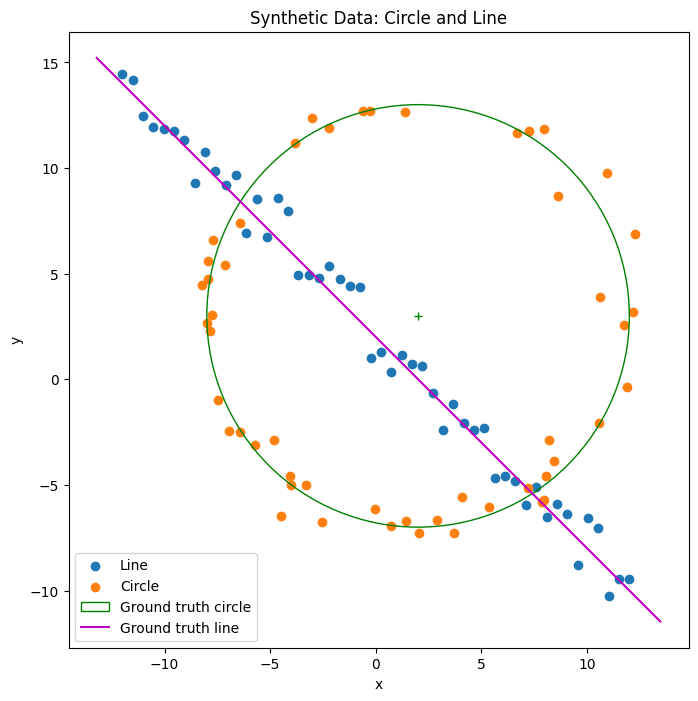

In [ ]:
import numpy as np
from scipy.optimize import minimize
from scipy import linalg
import matplotlib.pyplot as plt
# import tikzplotlib

# np.random.seed(0)  # Uncomment for reproducibility
N = 100
half_n = N // 2
r = 10
x0_gt, y0_gt = 2, 3  # Circle center
s = r / 16

# Circle points
t = np.random.uniform(0, 2 * np.pi, half_n)
n = s * np.random.randn(half_n)
x = x0_gt + (r + n) * np.cos(t)
y = y0_gt + (r + n) * np.sin(t)
X_circ = np.hstack((x.reshape(half_n, 1), y.reshape(half_n, 1)))

# Line points
s = 1.0
m, b = -1, 2
x = np.linspace(-12, 12, half_n)
y = m * x + b + s * np.random.randn(half_n)
X_line = np.hstack((x.reshape(half_n, 1), y.reshape(half_n, 1)))

# Combine all points
X = np.vstack((X_circ, X_line))

# Plot
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.scatter(X_line[:, 0], X_line[:, 1], label='Line')
ax.scatter(X_circ[:, 0], X_circ[:, 1], label='Circle')

# Ground truth circle
circle_gt = plt.Circle((x0_gt, y0_gt), r, color='g', fill=False, label='Ground truth circle')
ax.add_patch(circle_gt)
ax.plot((x0_gt), (y0_gt), '+', color='g')

# Ground truth line
x_min, x_max = ax.get_xlim()
x_ = np.array([x_min, x_max])
y_ = m * x_ + b
plt.plot(x_, y_, color='m', label='Ground truth line')

plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.title('Synthetic Data: Circle and Line')
plt.axis('equal')
plt.show()


In [36]:
def compute_line_normal(p_start, p_end):
    """
    Compute line in normal form: ax + by + c = 0
    where ||[a,b]|| = 1
    """
    (x0, y0), (x1, y1) = p_start, p_end
    delta_x, delta_y = x1 - x0, y1 - y0
    # perpendicular vector
    a, b = delta_y, -delta_x
    norm = np.hypot(a, b)
    a, b = a / norm, b / norm
    c = -(a*x0 + b*y0)
    return a, b, c

def perpendicular_distance(points, a, b, c):
    """Return perpendicular distances from points to line ax + by + c = 0"""
    return np.abs(a*points[:,0] + b*points[:,1] + c)

def ransac_line_fit(points, iterations=1000, threshold=0.7, min_pts=30):
    best_line = None
    best_inlier_idx = np.array([], dtype=int)
    
    for _ in range(iterations):
        idx = np.random.choice(len(points), 2, replace=False)
        p1, p2 = points[idx]
        a, b, c = compute_line_normal(p1, p2)
        
        distances = perpendicular_distance(points, a, b, c)
        inliers = np.where(distances < threshold)[0]
        
        if len(inliers) > len(best_inlier_idx) and len(inliers) >= min_pts:
            best_inlier_idx = inliers
            best_line = (a, b, c)
    
    if best_line is None:
        print("RANSAC failed to find a line. Try increasing threshold or iterations.")
    
    return best_line, best_inlier_idx




Line parameters: a=0.711, b=0.703, c=-1.650
||[a,b]|| = 1.000
Inliers detected: 38 / 100


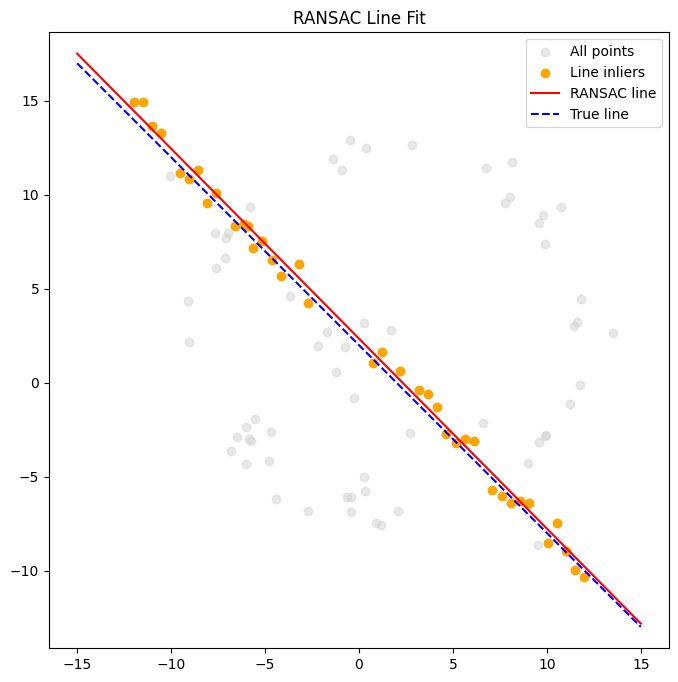

In [49]:
# Run RANSAC
line_model, inlier_indices = ransac_line_fit(X, iterations=1000, threshold=0.7, min_pts=30)
a, b, c = line_model

print(f"Line parameters: a={a:.3f}, b={b:.3f}, c={c:.3f}")
print(f"||[a,b]|| = {np.linalg.norm([a,b]):.3f}")
print(f"Inliers detected: {len(inlier_indices)} / {len(X)}")

# Visualization
plt.figure(figsize=(8,8))
plt.scatter(X[:,0], X[:,1], color='lightgray', alpha=0.5, label='All points')
plt.scatter(X[inlier_indices,0], X[inlier_indices,1], color='orange', label='Line inliers')

# Estimated line
x_vals = np.linspace(-15, 15, 100)
y_vals = (-a*x_vals - c)/b
plt.plot(x_vals, y_vals, 'r-', label='RANSAC line')

# Ground truth line
y_gt = m_true * x_vals + b_true
plt.plot(x_vals, y_gt, 'b--', label='True line')

plt.axis('equal')
plt.legend()
plt.title("RANSAC Line Fit")
plt.show()

In [38]:
def circle_from_3points(pt1, pt2, pt3):
    """
    Compute circle passing through 3 points.
    Returns center (cx, cy) and radius r, or None if points are collinear.
    """
    A = np.array([
        [2*(pt2[0]-pt1[0]), 2*(pt2[1]-pt1[1])],
        [2*(pt3[0]-pt1[0]), 2*(pt3[1]-pt1[1])]
    ])
    B = np.array([
        pt2[0]**2 + pt2[1]**2 - pt1[0]**2 - pt1[1]**2,
        pt3[0]**2 + pt3[1]**2 - pt1[0]**2 - pt1[1]**2
    ])
    try:
        center = np.linalg.solve(A, B)
        radius = np.linalg.norm(center - pt1)
        return center[0], center[1], radius
    except np.linalg.LinAlgError:
        return None

def radial_distances(points, cx, cy, r):
    """Return radial distance error from circle for all points"""
    return np.abs(np.linalg.norm(points - np.array([cx, cy]), axis=1) - r)

def ransac_circle_fit(points, iterations=1000, threshold=0.7, min_pts=25):
    """
    RANSAC to fit a circle.
    Returns: best_model = (cx, cy, r), best_inliers = indices
    """
    best_inlier_idx = np.array([], dtype=int)
    best_model = None
    N = len(points)

    for _ in range(iterations):
        idx = np.random.choice(N, 3, replace=False)
        p1, p2, p3 = points[idx]
        circle = circle_from_3points(p1, p2, p3)
        if circle is None:
            continue
        cx, cy, r = circle
        errors = radial_distances(points, cx, cy, r)
        inliers = np.where(errors < threshold)[0]

        if len(inliers) > len(best_inlier_idx) and len(inliers) >= min_pts:
            best_inlier_idx = inliers
            best_model = (cx, cy, r)

    # Optional: refine using all inliers
    if best_model is not None and len(best_inlier_idx) >= 3:
        def loss(params):
            cx, cy, r = params
            return np.sum((np.linalg.norm(points[best_inlier_idx] - np.array([cx, cy]), axis=1) - r)**2)
        res = minimize(loss, best_model)
        best_model = res.x

    return best_model, best_inlier_idx



In [39]:
# Mask out line inliers
mask = np.ones(len(X), dtype=bool)
mask[best_inliers] = False
X_remaining = X[mask]

# Fit circle
circle_model, circle_inliers = ransac_circle_fit(X_remaining, iterations=1000, threshold=0.7, min_pts=30)
cx, cy, r = circle_model

print(f"Estimated circle: center=({cx:.3f}, {cy:.3f}), radius={r:.3f}")
print(f"Circle inliers: {len(circle_inliers)} / {len(X_remaining)}")



Estimated circle: center=(1.631, 2.606), radius=9.986
Circle inliers: 36 / 64


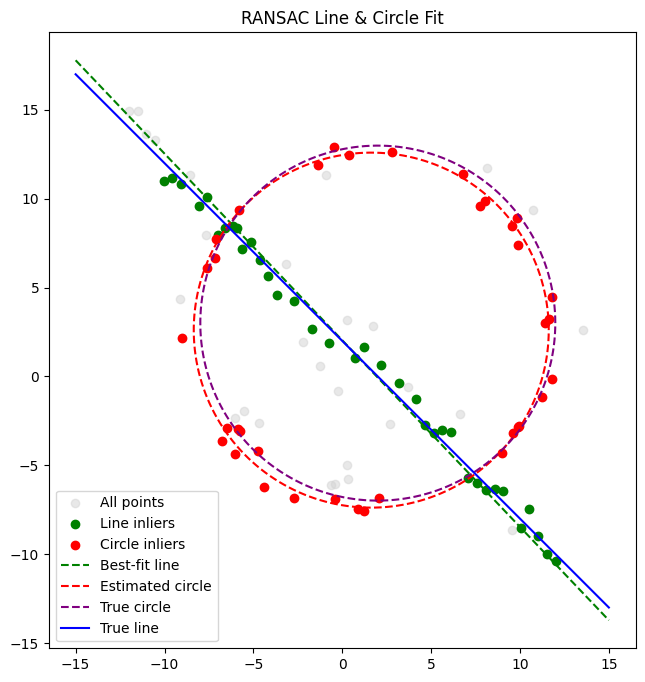

In [47]:

plt.figure(figsize=(8,8))
plt.scatter(X[:,0], X[:,1], color='lightgray', alpha=0.5, label='All points')
plt.scatter(X[best_inliers,0], X[best_inliers,1], color='green', label='Line inliers')
plt.scatter(X_remaining[circle_inliers,0], X_remaining[circle_inliers,1], color='red', label='Circle inliers')

# Plot RANSAC line
x_vals = np.linspace(-15, 15, 100)
y_vals = (-a*x_vals - d)/b
plt.plot(x_vals, y_vals, 'g--', label='Best-fit line')

# Plot RANSAC circle
theta = np.linspace(0, 2*np.pi, 200)
plt.plot(cx + r*np.cos(theta), cy + r*np.sin(theta), 'r--', label='Estimated circle')

# Ground truth
plt.plot(x0_gt + r*np.cos(theta), y0_gt + r*np.sin(theta), 'purple', linestyle='--', label='True circle')
y_gt = m_true * x_vals + b_true
plt.plot(x_vals, y_gt, 'b-', label='True line')
#plt.scatter(x0_gt, y0_gt, color='purple', marker='x', s=100, label='True circle center')

plt.gca().set_aspect('equal')
plt.legend()
plt.title("RANSAC Line & Circle Fit")
plt.show()


Circle-first estimate: center=(1.735, 2.526), radius=9.910
Number of inliers (circle first): 40 / 100
Line-after-circle: a=0.711, b=0.703, d=-1.652, inliers=33


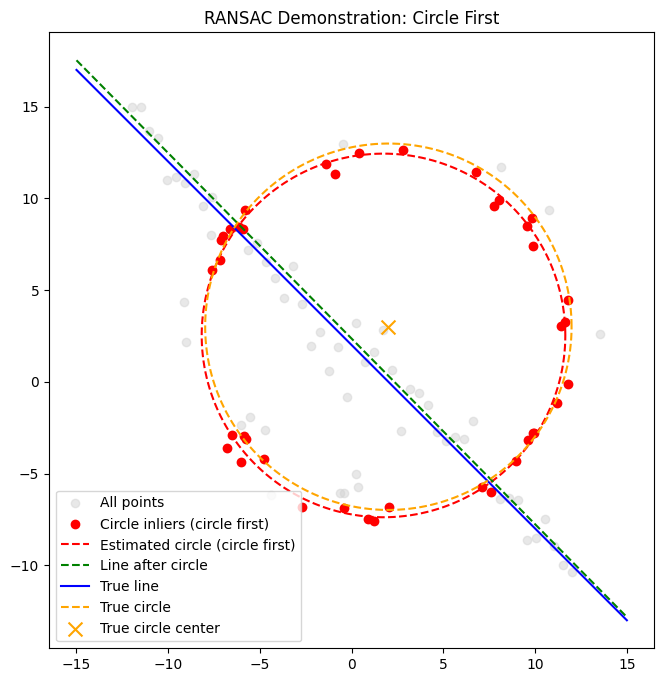

In [51]:

# Fit circle using all points first
circle_model_cf, inliers_cf = ransac_circle_fit(X, iterations=1000, threshold=0.7, min_pts=25)
cx_cf, cy_cf, r_cf = circle_model_cf

print(f"Circle-first estimate: center=({cx_cf:.3f}, {cy_cf:.3f}), radius={r_cf:.3f}")
print(f"Number of inliers (circle first): {len(inliers_cf)} / {len(X)}")

# Mask out circle inliers to fit line afterward
mask_line = np.ones(len(X), dtype=bool)
mask_line[inliers_cf] = False
X_remaining_line = X[mask_line]

# Fit line on remaining points (after circle removal)
line_model_after, inliers_line_after = ransac_line(X_remaining_line, n_iterations=1000, dist_threshold=0.7, min_inliers=30)
a_line_after, b_line_after, d_line_after = line_model_after

print(f"Line-after-circle: a={a_line_after:.3f}, b={b_line_after:.3f}, d={d_line_after:.3f}, inliers={len(inliers_line_after)}")

# -------------------------------
# Plot results
# -------------------------------
plt.figure(figsize=(8,8))
plt.scatter(X[:,0], X[:,1], color='lightgray', alpha=0.5, label='All points')

# Circle inliers (circle first)
plt.scatter(X[inliers_cf,0], X[inliers_cf,1], color='red', label='Circle inliers (circle first)')

# Circle estimate
theta = np.linspace(0, 2*np.pi, 200)
plt.plot(cx_cf + r_cf*np.cos(theta), cy_cf + r_cf*np.sin(theta), 'r--', label='Estimated circle (circle first)')

# Line estimate after removing circle inliers
x_vals = np.linspace(-15, 15, 100)
y_vals_line_after = (-a_line_after*x_vals - d_line_after)/b_line_after
plt.plot(x_vals, y_vals_line_after, 'g--', label='Line after circle')

# Ground truth line and circle
plt.plot(x_vals, m_true*x_vals + b_true, 'b-', label='True line')
plt.plot(x0_gt + r*np.cos(theta), y0_gt + r*np.sin(theta), 'orange', linestyle='--', label='True circle')
plt.scatter(x0_gt, y0_gt, color='orange', marker='x', s=100, label='True circle center')

plt.gca().set_aspect('equal')
plt.legend()
plt.title("RANSAC Demonstration: Circle First")
plt.show()
